In [2]:
# ============================================
# EXPERIMENT 3
# Random Forest Classification of Cyber Attacks
# Using HIKARI-2021 Dataset
# ============================================

# 1. Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [4]:

# ============================================
# 2. Load a representative sample
# ============================================

file_path = "ALLFLOWMETER_HIKARI2021.csv"

chunks = []

for chunk in pd.read_csv(file_path, chunksize=50000):

    # Take a random sample from each chunk
    sample = chunk.sample(
        n=min(5000, len(chunk)),
        random_state=42
    )

    chunks.append(sample)

# Combine samples
df = pd.concat(chunks, ignore_index=True)

print("Sampled dataset shape:", df.shape)

Sampled dataset shape: (60000, 88)


In [5]:
# ============================================
# 3. Display basic information
# ============================================

print("\nFirst 5 rows:")
print(df.head())

print("\nNumber of columns:", len(df.columns))


First 5 rows:
   Unnamed: 0.1  Unnamed: 0                 uid        originh  originp  \
0         33553       22524    CUGBzta9efeTlpob  103.255.15.27    44902   
1          9427        4282  CZxRzx1wdfcU8aSQai  103.255.15.23    10327   
2           199         199  Cec5z33r2NlwjecLfl  103.255.15.23    13760   
3         12447        1418  C5eunq2XIGMxyIHsdc  103.255.15.23    16638   
4         39489       28460   CKhUbT1pV6Rdzu8zP  103.255.15.23    39217   

           responh  responp  flow_duration  fwd_pkts_tot  bwd_pkts_tot  ...  \
0    103.255.15.23    42000       0.000136             1             1  ...   
1    128.199.88.81      443       2.933513            44            39  ...   
2  128.199.242.104      443       0.457453            13            13  ...   
3    52.46.153.177      443       5.908058            12            10  ...   
4          8.8.8.8       53       0.054741             2             2  ...   

   idle.min  idle.max  idle.tot  idle.avg  idle.std  fwd_in

In [6]:
# ============================================
# 4. Check target distribution
# ============================================

print("\nAttack / Normal Distribution:")
print(df["Label"].value_counts())


Attack / Normal Distribution:
Label
0    51781
1     8219
Name: count, dtype: int64


In [7]:
# ============================================
# 5. Remove unnecessary columns
# ============================================

columns_to_drop = [
    "Unnamed: 0.1",
    "Unnamed: 0",
    "uid",
    "origin",
    "origip",
    "resp_h",
    "traffic_category"
]

# Drop only columns that actually exist
columns_to_drop = [
    col for col in columns_to_drop
    if col in df.columns
]

df = df.drop(columns=columns_to_drop)

In [8]:
# ============================================
# 6. Separate features and target
# ============================================

X = df.drop(columns=["Label"])
y = df["Label"]


In [9]:
# ============================================
# 7. Keep numerical features
# ============================================

X = X.select_dtypes(include=[np.number])


print("\nNumber of features used:", X.shape[1])


Number of features used: 81


In [10]:
# ============================================
# 8. Handle infinite and missing values
# ============================================

X = X.replace([np.inf, -np.inf], np.nan)

X = X.fillna(X.median())

In [11]:
# ============================================
# 9. Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 48000
Testing samples: 12000


In [12]:
# ============================================
# 10. Create Random Forest Classifier
# ============================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)


In [13]:
# ============================================
# 11. Train the model
# ============================================

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [14]:
# ============================================
# 12. Make predictions
# ============================================

y_pred = rf.predict(X_test)

In [15]:
# ============================================
# 13. Model Evaluation
# ============================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)


print("\n========== MODEL PERFORMANCE ==========")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)


========== MODEL PERFORMANCE ==========
Accuracy : 0.9170833333333334
Precision: 0.7286821705426356
Recall   : 0.6289537712895377
F1 Score : 0.6751550767221678


In [16]:
# ============================================
# 14. Confusion Matrix
# ============================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)



Confusion Matrix:
[[9971  385]
 [ 610 1034]]


In [17]:
# ============================================
# 15. Classification Report
# ============================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Attack"],
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.96      0.95     10356
      Attack       0.73      0.63      0.68      1644

    accuracy                           0.92     12000
   macro avg       0.84      0.80      0.81     12000
weighted avg       0.91      0.92      0.91     12000



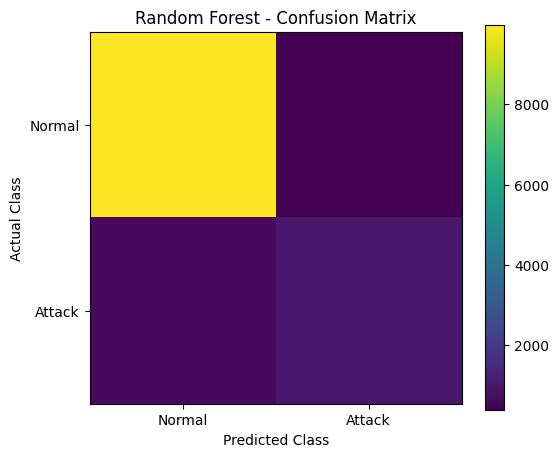

In [18]:
# ============================================
# 16. Plot Confusion Matrix
# ============================================

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks([0, 1], ["Normal", "Attack"])
plt.yticks([0, 1], ["Normal", "Attack"])

plt.colorbar()

plt.show()